In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from core.data import load_from_kaggle


e:\GitHub\dpp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_link = "sshikamaru/car-object-detection"
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

Destination directory '../data/raw\car-object-detection' already exists with files. Skipping download (replace=False).


In [3]:
dataset_name

'car-object-detection'

In [25]:
files

['data']

In [26]:
import os

files = os.listdir("../data/raw/car-object-detection/data")

files

['data.yaml',
 'images',
 'labels',
 'runs',
 'sample_submission.csv',
 'testing_images',
 'training_images',
 'train_solution_bounding_boxes (1).csv']

In [27]:
df = pd.read_csv("/".join(["../data/raw", dataset_name, 'data', files[-1]]))
df.head()

,image,xmin,ymin,xmax,ymax
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180
2,vid_4_10040.jpg,239.192475,176.764801,361.968162,236.430180
3,vid_4_10020.jpg,496.483358,172.363256,630.020260,231.539575
4,vid_4_10060.jpg,16.630970,186.546010,132.558611,238.386422


In [28]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })


'Shape'

(559, 5)

'Description'

,count,mean,std,min,25%,50%,75%,max
xmin,559.0,263.39,207.37,0.00,61.39,236.75,446.84,645.18
ymin,559.0,186.52,9.32,148.40,180.11,187.52,193.88,208.06
xmax,559.0,365.32,213.50,28.56,166.31,348.59,571.32,676.00
ymax,559.0,231.50,13.99,198.32,223.23,230.56,237.90,308.32


'Duplicates'

np.int64(0)

,Data Types,Missing Values,Unique Values,Sample Values
image,object,0,355,"[vid_4_9600.jpg, vid_4_17560.jpg, vid_4_6360.jpg]"
xmin,float64,0,440,"[239.1924747, 614.8567294, 82.71522214]"
ymin,float64,0,149,"[188.9913127, 196.3528174, 196.8162806]"
xmax,float64,0,438,"[68.96960926, 118.3733719, 56.12818645]"
ymax,float64,0,184,"[217.8458816, 228.839864, 237.4083012]"


In [29]:
df.groupby('image').size().loc[lambda x: x > 1].sort_values(ascending=False)

image
vid_4_26460.jpg    7
vid_4_6240.jpg     6
vid_4_2000.jpg     5
vid_4_26380.jpg    5
vid_4_26420.jpg    5
                  ..
vid_4_9580.jpg     2
vid_4_9600.jpg     2
vid_4_9640.jpg     2
vid_4_9780.jpg     2
vid_4_9800.jpg     2
Length: 119, dtype: int64

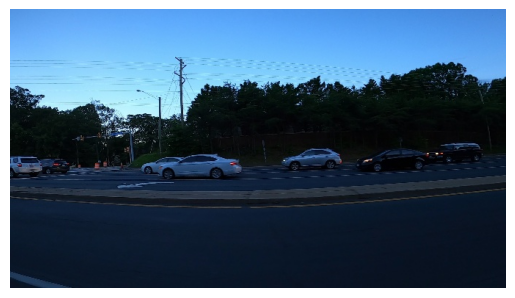

In [30]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

train_image_path = os.path.join("..", "data", "raw", dataset_name, "data", "training_images")

img = mpimg.imread(os.path.join(train_image_path, "vid_4_26460.jpg"))

plt.imshow(img)
plt.axis('off')
plt.show()

In [31]:
from PIL import Image

with Image.open(os.path.join(train_image_path, "vid_4_26460.jpg")) as img:
    print(img.size)

(676, 380)


In [32]:
for img_name in df.loc[:,'image'].unique():
    with Image.open(os.path.join(train_image_path, img_name)) as img:
        df.loc[df['image'] == img_name, 'image_width'] = img.size[0]
        df.loc[df['image'] == img_name, 'image_height'] = img.size[1]

df.head()

,image,xmin,ymin,xmax,ymax,image_width,image_height
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547,676.0,380.0
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180,676.0,380.0
2,vid_4_10040.jpg,239.192475,176.764801,361.968162,236.430180,676.0,380.0
3,vid_4_10020.jpg,496.483358,172.363256,630.020260,231.539575,676.0,380.0
4,vid_4_10060.jpg,16.630970,186.546010,132.558611,238.386422,676.0,380.0


In [33]:
for idx in df.index:
    df.loc[idx,'x_center'] = (df.loc[idx, 'xmin'] + df.loc[idx, 'xmax']) / 2 / df.loc[idx, 'image_width']
    df.loc[idx,'y_center'] = (df.loc[idx, 'ymin'] + df.loc[idx, 'ymax']) / 2 / df.loc[idx, 'image_height']
    df.loc[idx,'width'] = (df.loc[idx, 'xmax'] - df.loc[idx, 'xmin']) / df.loc[idx, 'image_width']
    df.loc[idx,'height'] = (df.loc[idx, 'ymax'] - df.loc[idx, 'ymin']) / df.loc[idx, 'image_height']

df.head()

,image,xmin,ymin,xmax,ymax,image_width,image_height,x_center,y_center,width,height
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547,676.0,380.0,0.450434,0.539817,0.068741,0.095238
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180,676.0,380.0,0.100217,0.557191,0.155572,0.129987
2,vid_4_10040.jpg,239.192475,176.764801,361.968162,236.430180,676.0,380.0,0.444645,0.543678,0.181621,0.157014
3,vid_4_10020.jpg,496.483358,172.363256,630.020260,231.539575,676.0,380.0,0.833213,0.531451,0.197540,0.155727
4,vid_4_10060.jpg,16.630970,186.546010,132.558611,238.386422,676.0,380.0,0.110347,0.559122,0.171491,0.136422


In [34]:
from sklearn.model_selection import train_test_split

img_all = os.listdir(f'../data/raw/{dataset_name}/data/training_images')

img_train, img_val = train_test_split(img_all,
                                      test_size=0.15,
                                      random_state=42)

print(img_train)
print('\n',img_val)

['vid_4_13640.jpg', 'vid_4_3400.jpg', 'vid_4_1980.jpg', 'vid_4_880.jpg', 'vid_4_20560.jpg', 'vid_4_1740.jpg', 'vid_4_29920.jpg', 'vid_4_11100.jpg', 'vid_4_3280.jpg', 'vid_4_2320.jpg', 'vid_4_26240.jpg', 'vid_4_25960.jpg', 'vid_4_26720.jpg', 'vid_4_23140.jpg', 'vid_4_26340.jpg', 'vid_4_17180.jpg', 'vid_4_5720.jpg', 'vid_4_17480.jpg', 'vid_4_17400.jpg', 'vid_4_1840.jpg', 'vid_4_21020.jpg', 'vid_4_12320.jpg', 'vid_4_980.jpg', 'vid_4_21160.jpg', 'vid_4_18420.jpg', 'vid_4_16240.jpg', 'vid_4_1640.jpg', 'vid_4_22860.jpg', 'vid_4_26520.jpg', 'vid_4_21300.jpg', 'vid_4_2440.jpg', 'vid_4_18840.jpg', 'vid_4_21920.jpg', 'vid_4_29400.jpg', 'vid_4_12860.jpg', 'vid_4_18280.jpg', 'vid_4_1860.jpg', 'vid_4_7760.jpg', 'vid_4_29940.jpg', 'vid_4_9040.jpg', 'vid_4_3960.jpg', 'vid_4_22900.jpg', 'vid_4_14500.jpg', 'vid_4_14780.jpg', 'vid_4_19400.jpg', 'vid_4_17800.jpg', 'vid_4_14680.jpg', 'vid_4_9820.jpg', 'vid_4_11460.jpg', 'vid_4_10520.jpg', 'vid_4_22080.jpg', 'vid_4_27120.jpg', 'vid_4_22480.jpg', 'vid_4_258

In [35]:
import shutil

os.makedirs(f'../data/raw/{dataset_name}/data/images/train', exist_ok=True)
os.makedirs(f'../data/raw/{dataset_name}/data/images/val', exist_ok=True)

for img in img_train:
    shutil.move(os.path.join(f'../data/raw/{dataset_name}/data/training_images', img),
                os.path.join(f'../data/raw/{dataset_name}/data/images/train', img))
    
for img in img_val:
    shutil.move(os.path.join(f'../data/raw/{dataset_name}/data/training_images', img),
                os.path.join(f'../data/raw/{dataset_name}/data/images/val', img))

In [36]:
os.makedirs(f'../data/raw/{dataset_name}/data/labels/train', exist_ok=True)
os.makedirs(f'../data/raw/{dataset_name}/data/labels/val', exist_ok=True)

img_grouped = df.groupby('image')

for img in img_train:
    label_file = img.replace('.jpg', '.txt')
    path = os.path.join(f'../data/raw/{dataset_name}/data/labels/train', label_file)

    if img in img_grouped.groups:
        with open(path, 'w') as f:
            for _, r in img_grouped.get_group(img).iterrows():
                f.write(f'0 {r.x_center} {r.y_center} {r.width} {r.height}\n')
    else:
        open(path, 'w').close()

for img in img_val:
    label_file = img.replace('.jpg', '.txt')
    path = os.path.join(f'../data/raw/{dataset_name}/data/labels/val', label_file)

    if img in img_grouped.groups:
        with open(path, 'w') as f:
            for _, r in img_grouped.get_group(img).iterrows():
                f.write(f'0 {r.x_center} {r.y_center} {r.width} {r.height}\n')
    else:
        open(path, 'w').close()

In [37]:
import yaml

data_dict = {
            'train': 'images/train',
            'val': 'images/val',
            'nc': 1,
            'names': ['car']
}

with open(f'../data/raw/{dataset_name}/data/data.yaml', 'w') as f:
    yaml.dump(data_dict, f)

In [3]:
from ultralytics import YOLO
import os

os.makedirs(f'../data/raw/{dataset_name}/data/runs/detect', exist_ok=True)

model = YOLO('yolo11n.pt')

model.train(
            data=f'../data/raw/{dataset_name}/data/data.yaml',
            epochs=100,
            seed=42,
            device=0,
            patience=20,
            name=f'{dataset_name}_base',
            project=f'../data/raw/{dataset_name}/data/runs/detect',
            verbose=False
)

New https://pypi.org/project/ultralytics/8.3.253 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car-ob

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001D604F9B3F0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [5]:
base_results = pd.read_csv(f'../data/raw/{dataset_name}/data/runs/detect/{dataset_name}_base/results.csv')

base_results.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,11.4730,1.41338,3.15796,1.17442,0.00168,0.96203,0.18261,0.12428,1.21034,3.93258,1.08039,0.000654,0.000654,0.000654
1,2,19.7530,1.38120,2.55263,1.20157,1.00000,0.28245,0.68862,0.35590,1.68563,3.64559,1.34256,0.001308,0.001308,0.001308
2,3,27.8045,1.44751,1.95908,1.23256,0.93502,0.84810,0.92862,0.56996,1.32397,1.89894,1.18821,0.001948,0.001948,0.001948
3,4,35.7577,1.43431,1.50637,1.22891,0.98596,0.88881,0.96197,0.58013,1.31520,1.57057,1.17050,0.001941,0.001941,0.001941
4,5,43.9843,1.38205,1.27864,1.21445,0.75817,0.91277,0.89949,0.49659,1.32844,1.75448,1.22057,0.001921,0.001921,0.001921


In [6]:
base_results.loc[base_results['metrics/mAP50-95(B)'] == base_results['metrics/mAP50-95(B)'].max(),:]

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
69,70,570.57,0.95075,0.46454,0.991,0.97017,0.97468,0.9797,0.70537,1.11112,0.50357,1.05795,0.000634,0.000634,0.000634


In [7]:
from ultralytics import YOLO

lr_list = [0.02, 0.01, 0.005, 0.001]

for lr in lr_list:
    model = YOLO('yolo11n.pt')

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                seed=42,
                lr0=lr,
                device=0,
                name=f'{dataset_name}_lr_{lr}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.3.253 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.02, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car-ob

In [8]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

lr = [0.02, 0.01, 0.005, 0.001]

for run in lr:
    result_path = os.path.join(run_dir, f'{dataset_name}_lr_{run}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'lr_{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
69,lr_0.02,0.70537,0.97017,0.97468
69,lr_0.01,0.70537,0.97017,0.97468
69,lr_0.005,0.70537,0.97017,0.97468
69,lr_0.001,0.70537,0.97017,0.97468


<Figure size 640x480 with 0 Axes>

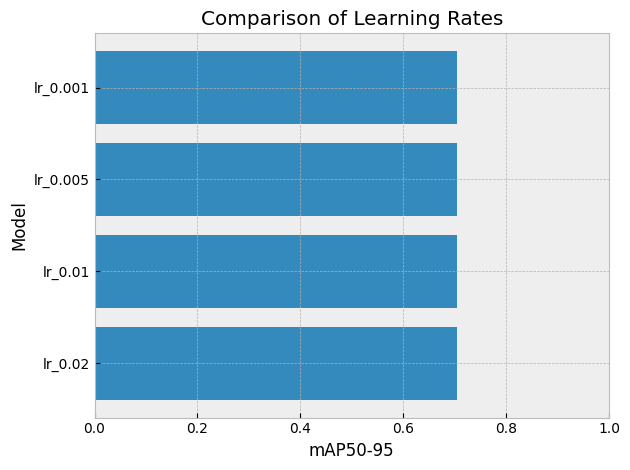

In [9]:
%matplotlib inline

plt.style.use('bmh')
plt.clf()

fig, ax = plt.subplots()

ax.barh(df_lr['model'], df_lr['metrics/mAP50-95(B)'])

ax.set_xlabel('mAP50-95')
ax.set_xlim(0, 1.0)
ax.set_ylabel('Model')
ax.set_title('Comparison of Learning Rates')
plt.tight_layout()
plt.show();

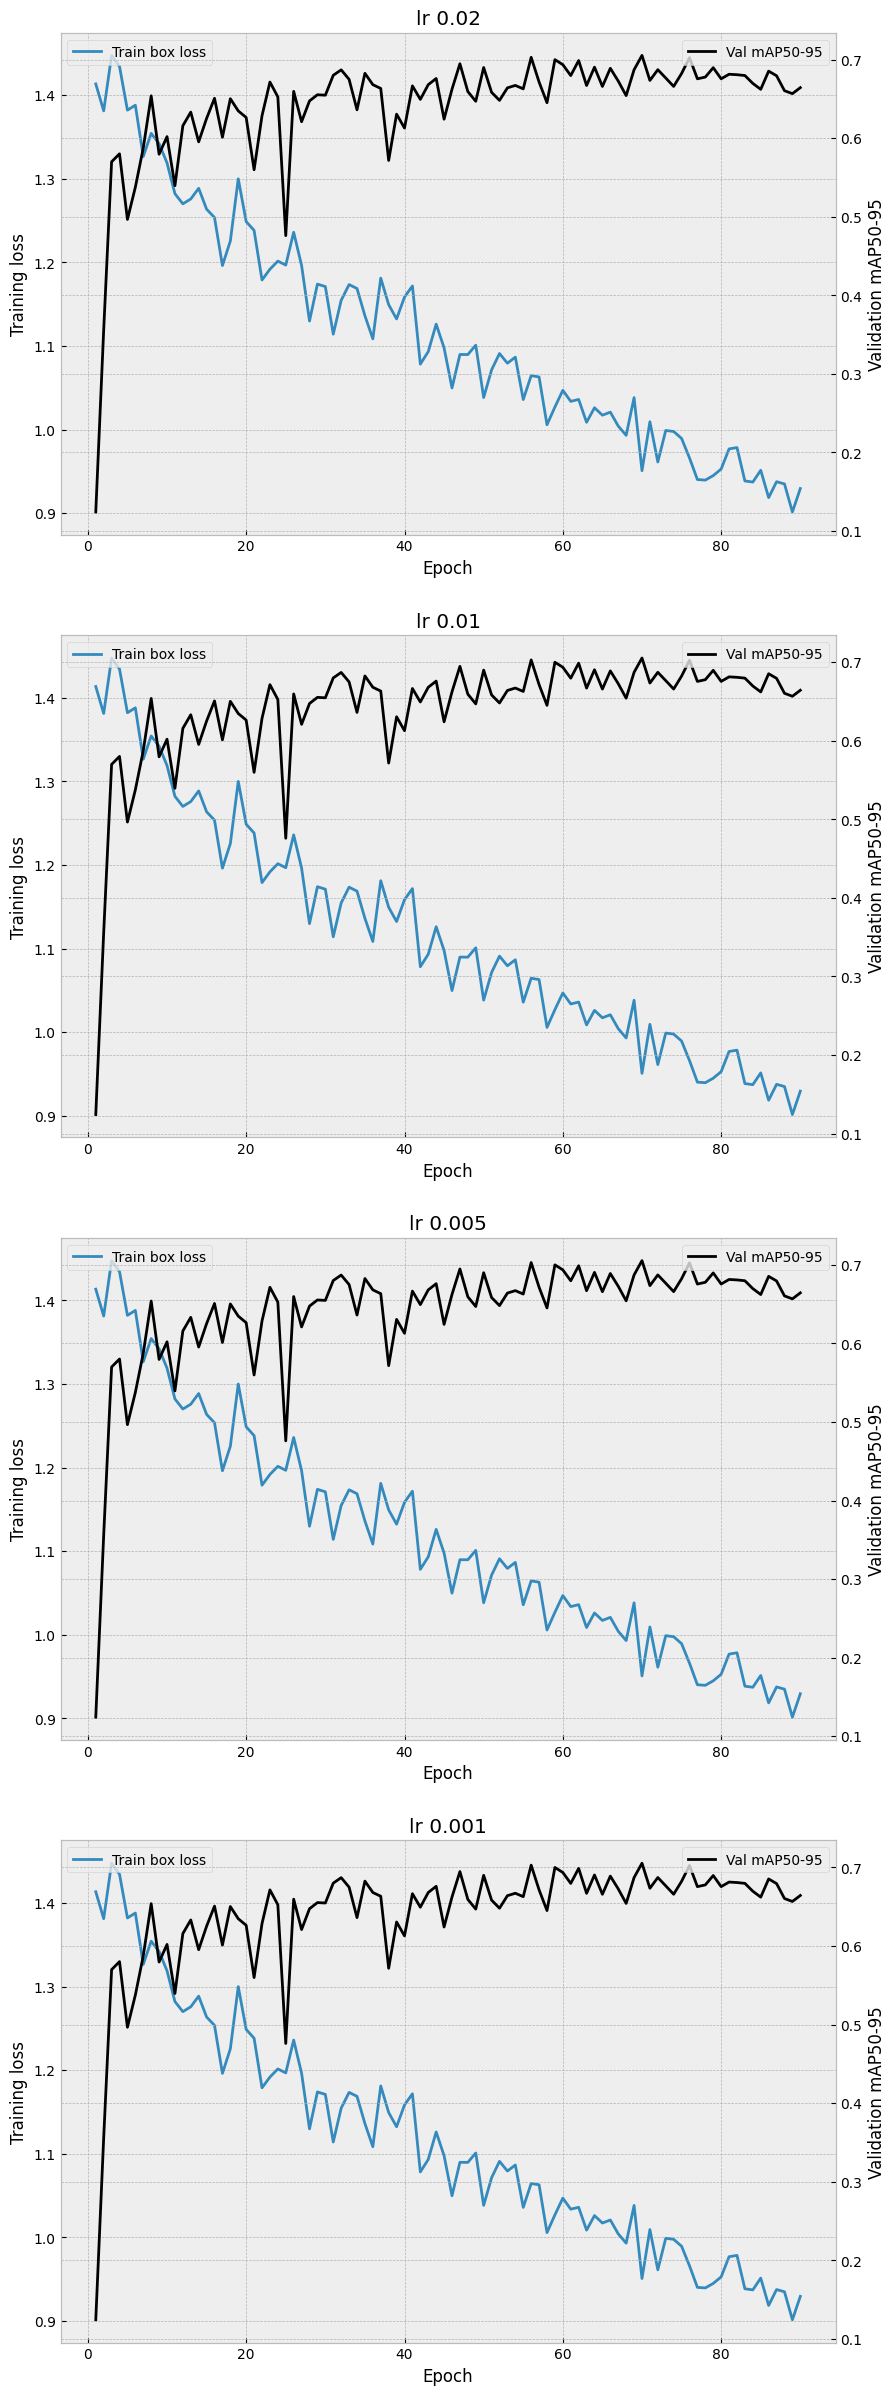

In [10]:
run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

lr = [0.02, 0.01, 0.005, 0.001]

fig, ax = plt.subplots(nrows=4, figsize=[10,30])

for n, run in enumerate(lr):
    
    df = pd.read_csv(f'../data/raw/{dataset_name}/data/runs/detect/{dataset_name}_lr_{run}/results.csv')

    ax[n].plot(df['epoch'], df['train/box_loss'], label='Train box loss')
    ax[n].set_xlabel('Epoch')
    ax[n].set_ylabel('Training loss')
    ax[n].set_title(f'lr {run}')

    axv = ax[n].twinx()
    axv.plot(df['epoch'], df['metrics/mAP50-95(B)'], color='black', label='Val mAP50-95')
    axv.set_ylabel('Validation mAP50-95')

    ax[n].legend(loc='upper left')
    axv.legend(loc='upper right')

plt.show()

In [11]:
from ultralytics import YOLO

img_size = [512, 640, 768]

for size in img_size:
    model = YOLO('yolo11n.pt')

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                seed=42,
                imgsz=size,
                lr0=0.01,
                device=0,
                name=f'{dataset_name}_imgsz_{size}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.3.253 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car-ob

In [12]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

img_size = [512, 640, 768]

for run in img_size:
    result_path = os.path.join(run_dir, f'{dataset_name}_imgsz_{run}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'imgsz_{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
69,imgsz_512,0.71342,0.97109,0.94937
36,imgsz_768,0.70993,0.95196,0.97468
69,imgsz_640,0.70537,0.97017,0.97468


In [13]:
from ultralytics import YOLO

hue_list = [0, 0.015, 0.025, 0.035, 0.045]

for hue in hue_list:
    model = YOLO('yolo11n.pt')

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                seed=42,
                imgsz=512,
                lr0=0.01,
                hsv_h=hue,
                device=0,
                name=f'{dataset_name}_hsv_h_{hue}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.3.253 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car-object

In [14]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

hue_list = [0.015, 0.025, 0.035, 0.045]

for run in hue_list:
    result_path = os.path.join(run_dir, f'{dataset_name}_hsv_h_{run}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'hsv_h_{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
80,hsv_h_0.045,0.72468,0.96708,0.94937
69,hsv_h_0.015,0.71342,0.97109,0.94937
69,hsv_h_0.025,0.71172,0.96195,0.97468
35,hsv_h_0.035,0.68915,0.96722,0.97468


In [ ]:
from ultralytics import YOLO

hue_list = [0.055, 0.065]

for hue in hue_list:
    model = YOLO('yolo11n.pt')

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                seed=42,
                imgsz=512,
                lr0=0.01,
                hsv_h=hue,
                device=0,
                name=f'{dataset_name}_hsv_h_{hue}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.3.253 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.055, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car-ob

In [18]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

hue_list = [0, 0.015, 0.025, 0.035, 0.045, 0.055, 0.065]

for run in hue_list:
    result_path = os.path.join(run_dir, f'{dataset_name}_hsv_h_{run}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'hsv_h_{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
80,hsv_h_0.045,0.72468,0.96708,0.94937
69,hsv_h_0.015,0.71342,0.97109,0.94937
69,hsv_h_0.025,0.71172,0.96195,0.97468
46,hsv_h_0.065,0.71131,0.95913,0.96203
71,hsv_h_0,0.70686,0.93734,0.97468
40,hsv_h_0.055,0.69759,0.95798,0.96203
35,hsv_h_0.035,0.68915,0.96722,0.97468


In [19]:
from ultralytics import YOLO

saturation_list = [0, 0.3, 0.5, 0.7, 0.9]

for saturation in saturation_list:
    model = YOLO('yolo11n.pt')

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                seed=42,
                imgsz=512,
                lr0=0.01,
                hsv_h=0.045,
                hsv_s=saturation,
                device=0,
                name=f'{dataset_name}_hsv_s_{saturation}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.3.253 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.045, hsv_s=0, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car-obje

In [20]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

saturation_list = [0, 0.3, 0.5, 0.7, 0.9]

for run in saturation_list:
    result_path = os.path.join(run_dir, f'{dataset_name}_hsv_s_{run}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'hsv_s_{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
80,hsv_s_0.7,0.72468,0.96708,0.94937
75,hsv_s_0.5,0.72223,0.95662,0.96203
74,hsv_s_0.3,0.72163,0.96290,0.98550
30,hsv_s_0.9,0.69427,0.97715,0.96203
34,hsv_s_0,0.67923,0.91763,0.98714


In [21]:
from ultralytics import YOLO

value_list = [0, 0.2, 0.4, 0.6, 0.8]

for value in value_list:
    model = YOLO('yolo11n.pt')

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                seed=42,
                imgsz=512,
                lr0=0.01,
                hsv_h=0.045,
                hsv_s=0.7,
                hsv_v=value,
                device=0,
                name=f'{dataset_name}_hsv_v_{value}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.4.0 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.045, hsv_s=0.7, hsv_v=0, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car-object

In [22]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

value_list = [0, 0.2, 0.4, 0.6, 0.8]

for run in value_list:
    result_path = os.path.join(run_dir, f'{dataset_name}_hsv_v_{run}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'hsv_v_{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
80,hsv_v_0.4,0.72468,0.96708,0.94937
94,hsv_v_0,0.71411,0.95083,0.98734
40,hsv_v_0.2,0.70512,0.96274,0.98117
30,hsv_v_0.8,0.68855,0.96485,0.93671
22,hsv_v_0.6,0.68737,0.96196,0.96037


In [3]:
from ultralytics import YOLO

degree_list = [0, 10, 30]

for degree in degree_list:
    model = YOLO('yolo11n.pt')

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                seed=42,
                imgsz=512,
                lr0=0.01,
                hsv_h=0.045,
                hsv_s=0.7,
                hsv_v=0.4,
                degrees=degree,
                device=0,
                name=f'{dataset_name}_degrees_{degree}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.4.0 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.045, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car-object

In [5]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

degree_list = [0, 10, 30]

for run in degree_list:
    result_path = os.path.join(run_dir, f'{dataset_name}_degrees_{run}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'degrees_{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
80,degrees_0,0.72468,0.96708,0.94937
97,degrees_30,0.70305,0.97454,0.96912
49,degrees_10,0.66388,0.96173,0.95424


In [6]:
from ultralytics import YOLO

scale_list = [0, 0.25, 0.5, 0.75]

for scale in scale_list:
    model = YOLO('yolo11n.pt')

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                seed=42,
                imgsz=512,
                lr0=0.01,
                hsv_h=0.045,
                hsv_s=0.7,
                hsv_v=0.4,
                degrees=0,
                scale=scale,
                device=0,
                name=f'{dataset_name}_scale_{scale}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.4.0 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.045, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car-object

In [7]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

scale_list = [0, 0.25, 0.5, 0.75]

for run in scale_list:
    result_path = os.path.join(run_dir, f'{dataset_name}_scale_{run}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'scale_{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
80,scale_0.5,0.72468,0.96708,0.94937
32,scale_0.25,0.69927,0.96107,0.96203
68,scale_0,0.69887,0.95619,0.94937
40,scale_0.75,0.69702,0.96911,0.96203


In [16]:
from ultralytics import YOLO

translate_list = [0, 0.1, 0.15, 0.2]

for translate in translate_list:
    model = YOLO('yolo11n.pt')

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                seed=42,
                imgsz=512,
                lr0=0.01,
                hsv_h=0.045,
                hsv_s=0.7,
                hsv_v=0.4,
                degrees=0,
                scale=0.5,
                translate=translate,
                device=0,
                name=f'{dataset_name}_translate_{translate}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.4.1 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.045, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car-object

In [17]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

translate_list = [0, 0.1, 0.15, 0.2]

for run in translate_list:
    result_path = os.path.join(run_dir, f'{dataset_name}_translate_{run}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'translate_{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
80,translate_0.1,0.72468,0.96708,0.94937
46,translate_0,0.70037,0.95009,0.96377
43,translate_0.2,0.69949,0.94983,0.95858
38,translate_0.15,0.69397,0.98680,0.94623


In [18]:
from ultralytics import YOLO

translate_list = [0.3]

for translate in translate_list:
    model = YOLO('yolo11n.pt')

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                seed=42,
                imgsz=512,
                lr0=0.01,
                hsv_h=0.045,
                hsv_s=0.7,
                hsv_v=0.4,
                degrees=0,
                scale=0.5,
                translate=translate,
                device=0,
                name=f'{dataset_name}_translate_{translate}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.4.1 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.045, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car-object

In [19]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

translate_list = [0, 0.1, 0.15, 0.2, 0.3]

for run in translate_list:
    result_path = os.path.join(run_dir, f'{dataset_name}_translate_{run}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'translate_{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
80,translate_0.1,0.72468,0.96708,0.94937
54,translate_0.3,0.71943,0.97842,0.97468
46,translate_0,0.70037,0.95009,0.96377
43,translate_0.2,0.69949,0.94983,0.95858
38,translate_0.15,0.69397,0.98680,0.94623


In [20]:
from ultralytics import YOLO

shear_list = [0, 0.1, 5]

for shear in shear_list:
    model = YOLO('yolo11n.pt')

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                seed=42,
                imgsz=512,
                lr0=0.01,
                hsv_h=0.045,
                hsv_s=0.7,
                hsv_v=0.4,
                degrees=0,
                scale=0.5,
                translate=0.1,
                shear=shear,
                device=0,
                name=f'{dataset_name}_shear_{shear}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.4.1 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.045, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car-object

In [22]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

shear_list = [0, 0.1, 5]

for run in shear_list:
    result_path = os.path.join(run_dir, f'{dataset_name}_shear_{run}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'shear_{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
80,shear_0,0.72468,0.96708,0.94937
46,shear_5,0.70357,0.97040,0.94937
22,shear_0.1,0.68890,0.96765,0.97468


In [23]:
from ultralytics import YOLO

fliplr_list = [0, 0.5]

for fliplr in fliplr_list:
    model = YOLO('yolo11n.pt')

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                seed=42,
                imgsz=512,
                lr0=0.01,
                hsv_h=0.045,
                hsv_s=0.7,
                hsv_v=0.4,
                degrees=0,
                scale=0.5,
                translate=0.1,
                shear=0,
                fliplr=fliplr,
                device=0,
                name=f'{dataset_name}_fliplr_{fliplr}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.4.2 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.045, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car-object-d

In [24]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

fliplr_list = [0, 0.5]

for run in fliplr_list:
    result_path = os.path.join(run_dir, f'{dataset_name}_fliplr_{run}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'fliplr_{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
80,fliplr_0.5,0.72468,0.96708,0.94937
35,fliplr_0,0.70607,0.98315,0.94937


In [3]:
from ultralytics import YOLO

flipud_list = [0, 0.5]

for flipud in flipud_list:
    model = YOLO('yolo11n.pt')

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                seed=42,
                imgsz=512,
                lr0=0.01,
                hsv_h=0.045,
                hsv_s=0.7,
                hsv_v=0.4,
                degrees=0,
                scale=0.5,
                translate=0.1,
                shear=0,
                fliplr=0.5,
                flipud=flipud,
                device=0,
                name=f'{dataset_name}_flipud_{flipud}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.4.2 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.045, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car-object-d

In [4]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

flipud_list = [0, 0.5]

for run in flipud_list:
    result_path = os.path.join(run_dir, f'{dataset_name}_flipud_{run}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'flipud_{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
80,flipud_0,0.72468,0.96708,0.94937
82,flipud_0.5,0.70806,0.97275,0.96203


In [5]:
from ultralytics import YOLO

mosaic_list = [0, 0.25, 0.5, 0.75, 1]

for mosaic in mosaic_list:
    model = YOLO('yolo11n.pt')

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                seed=42,
                imgsz=512,
                lr0=0.01,
                hsv_h=0.045,
                hsv_s=0.7,
                hsv_v=0.4,
                degrees=0,
                scale=0.5,
                translate=0.1,
                shear=0,
                fliplr=0.5,
                flipud=0,
                mosaic=mosaic,
                device=0,
                name=f'{dataset_name}_mosaic_{mosaic}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.4.2 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.045, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0, multi_scale=False, name=car-object-det

In [6]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

mosaic_list = [0, 0.25, 0.5, 0.75, 1]

for run in mosaic_list:
    result_path = os.path.join(run_dir, f'{dataset_name}_mosaic_{run}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'mosaic_{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
73,mosaic_0.25,0.72497,0.95843,0.96203
80,mosaic_1,0.72468,0.96708,0.94937
56,mosaic_0.5,0.71467,0.97084,0.97468
85,mosaic_0,0.71256,0.95733,0.94937
31,mosaic_0.75,0.70668,0.96086,0.96203


In [10]:
from ultralytics import YOLO

mixup_list = [0, 0.1, 0.25, 0.5, 0.75, 1]

for mixup in mixup_list:
    model = YOLO('yolo11n.pt')

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                seed=42,
                imgsz=512,
                lr0=0.01,
                hsv_h=0.045,
                hsv_s=0.7,
                hsv_v=0.4,
                degrees=0,
                scale=0.5,
                translate=0.1,
                shear=0,
                fliplr=0.5,
                flipud=0,
                mosaic=0.25,
                mixup=mixup,
                device=0,
                name=f'{dataset_name}_mixup_{mixup}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.4.2 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.045, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.25, multi_scale=False, name=car-object-

In [11]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

mixup_list = [0, 0.1, 0.25, 0.5, 0.75, 1]

for run in mixup_list:
    result_path = os.path.join(run_dir, f'{dataset_name}_mixup_{run}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'mixup_{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
73,mixup_0,0.72497,0.95843,0.96203
50,mixup_0.25,0.71164,0.98018,0.93671
54,mixup_0.5,0.70769,0.97506,0.93671
72,mixup_0.75,0.70461,0.97955,0.94937
96,mixup_0.1,0.70292,0.96875,0.96203
34,mixup_1,0.68638,0.97189,0.91139


In [12]:
from ultralytics import YOLO

copy_paste_list = [0, 0.1, 0.25, 0.5]

for copy_paste in copy_paste_list:
    model = YOLO('yolo11n.pt')

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                seed=42,
                imgsz=512,
                lr0=0.01,
                hsv_h=0.045,
                hsv_s=0.7,
                hsv_v=0.4,
                degrees=0,
                scale=0.5,
                translate=0.1,
                shear=0,
                fliplr=0.5,
                flipud=0,
                mosaic=0.25,
                mixup=0,
                copy_paste=copy_paste,
                device=0,
                name=f'{dataset_name}_copy_paste_{copy_paste}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.4.2 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.045, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.25, multi_scale=False, name=car-object-dete

In [13]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

copy_paste_list = [0, 0.1, 0.25, 0.5]

for run in copy_paste_list:
    result_path = os.path.join(run_dir, f'{dataset_name}_copy_paste_{run}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'copy_paste_{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
73,copy_paste_0,0.72497,0.95843,0.96203
73,copy_paste_0.1,0.72497,0.95843,0.96203
73,copy_paste_0.25,0.72497,0.95843,0.96203
73,copy_paste_0.5,0.72497,0.95843,0.96203


In [14]:
from ultralytics import YOLO

erasing_list = [0, 0.2, 0.4, 0.6, 0.8]

for erasing in erasing_list:
    model = YOLO('yolo11n.pt')

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                seed=42,
                imgsz=512,
                lr0=0.01,
                hsv_h=0.045,
                hsv_s=0.7,
                hsv_v=0.4,
                degrees=0,
                scale=0.5,
                translate=0.1,
                shear=0,
                fliplr=0.5,
                flipud=0,
                mosaic=0.25,
                mixup=0,
                copy_paste=0,
                erasing=erasing,
                device=0,
                name=f'{dataset_name}_erasing_{erasing}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.4.2 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0, exist_ok=False, fliplr=0.5, flipud=0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.045, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.25, multi_scale=False, name=car-object-detect

In [15]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

erasing_list = [0, 0.2, 0.4, 0.6, 0.8]

for run in erasing_list:
    result_path = os.path.join(run_dir, f'{dataset_name}_erasing_{run}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'erasing_{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
73,erasing_0,0.72497,0.95843,0.96203
73,erasing_0.2,0.72497,0.95843,0.96203
73,erasing_0.4,0.72497,0.95843,0.96203
73,erasing_0.6,0.72497,0.95843,0.96203
73,erasing_0.8,0.72497,0.95843,0.96203


In [16]:
from ultralytics import YOLO

batch_list = [4, 8, 16]

for batch in batch_list:
    model = YOLO('yolo11n.pt')

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                seed=42,
                imgsz=512,
                batch=batch,
                lr0=0.01,
                hsv_h=0.045,
                hsv_s=0.7,
                hsv_v=0.4,
                degrees=0,
                scale=0.5,
                translate=0.1,
                shear=0,
                fliplr=0.5,
                flipud=0,
                mosaic=0.25,
                mixup=0,
                copy_paste=0,
                erasing=0.4,
                device=0,
                name=f'{dataset_name}_batch_{batch}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.4.2 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.045, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.25, multi_scale=False, name=car-object-detec

In [17]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

batch_list = [4, 8, 16]

for run in batch_list:
    result_path = os.path.join(run_dir, f'{dataset_name}_batch_{run}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'batch_{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
73,batch_16,0.72497,0.95843,0.96203
98,batch_8,0.72220,0.97062,0.96203
62,batch_4,0.70462,0.96481,0.94937


In [20]:
from ultralytics import YOLO

model = YOLO('yolo11n.pt')

model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
            epochs=100,
            seed=42,
            imgsz=512,
            batch=16,
            lr0=0.01,
            hsv_h=0.045,
            hsv_s=0.7,
            hsv_v=0.4,
            degrees=0,
            scale=0.5,
            translate=0.1,
            shear=0,
            fliplr=0.5,
            flipud=0,
            mosaic=0.25,
            mixup=0,
            copy_paste=0,
            erasing=0.4,
            name=f'{dataset_name}_optimal',
            project=f'../data/raw/{dataset_name}/data/runs/detect',
            verbose=False,
            patience=20,
            plots=True
)

New https://pypi.org/project/ultralytics/8.4.2 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.045, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.25, multi_scale=False, name=car-object-dete

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002857EBD4750>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [21]:
import os

best_epochs = []

run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

model_list = ['base', 'optimal']

for run in model_list:
    result_path = os.path.join(run_dir, f'{dataset_name}_{run}/results.csv')
    df = pd.read_csv(result_path)
    best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
    best_row['model'] = os.path.basename(f'{run}')
    best_epochs.append(best_row)

df_lr = pd.DataFrame(best_epochs)

df_lr[['model', 'metrics/mAP50-95(B)', 'metrics/precision(B)', 'metrics/recall(B)']].sort_values('metrics/mAP50-95(B)', ascending=False)

,model,metrics/mAP50-95(B),metrics/precision(B),metrics/recall(B)
73,optimal,0.72497,0.95843,0.96203
69,base,0.70537,0.97017,0.97468


In [22]:
from ultralytics import YOLO

seed_list = [0, 24, 1501]

for seed in seed_list:

    model = YOLO('yolo11n.pt')

    model.train(
                data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                device=0,
                seed=seed,
                name=f'{dataset_name}_base_seed_{seed}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

    model = YOLO('yolo11n.pt')

    model.train(data=f'../data/raw/{dataset_name}/data/data.yaml',
                epochs=100,
                imgsz=512,
                batch=16,
                lr0=0.01,
                hsv_h=0.045,
                hsv_s=0.7,
                hsv_v=0.4,
                degrees=0,
                scale=0.5,
                translate=0.1,
                shear=0,
                fliplr=0.5,
                flipud=0,
                mosaic=0.25,
                mixup=0,
                copy_paste=0,
                erasing=0.4,
                seed=seed,
                name=f'{dataset_name}_optimal_e300_p100_seed_{seed}',
                project=f'../data/raw/{dataset_name}/data/runs/detect',
                verbose=False,
                patience=20
    )

New https://pypi.org/project/ultralytics/8.4.2 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.244  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/raw/car-object-detection/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car-obje

In [24]:
import os
from statistics import mean

seed_list = [0, 24, 42, 1501]

best_mAP50_95_base = []
best_mAP50_95_optimised = []

for seed in seed_list:

    best_epochs = []

    run_dir = f'../data/raw/{dataset_name}/data/runs/detect'

    model_list = [f'base_seed_{seed}', f'optimal_seed_{seed}']

    for run in model_list:
        result_path = os.path.join(run_dir, f'{dataset_name}_{run}/results.csv')
        df = pd.read_csv(result_path)
        best_row = df.loc[df['metrics/mAP50-95(B)'].idxmax()].copy()
        best_row['model'] = os.path.basename(f'{run}')
        best_epochs.append(best_row)

    best_mAP50_95_base.append(float(best_epochs[0]['metrics/mAP50-95(B)']))
    best_mAP50_95_optimised.append(float(best_epochs[1]['metrics/mAP50-95(B)']))

    df = pd.DataFrame(best_epochs)

    print(df[['model', 'metrics/mAP50-95(B)']].sort_values('metrics/mAP50-95(B)', ascending=False))

print('\nBase model average mAP50-95:\n', round(mean(best_mAP50_95_base) *100, 2),'%\n')
print('Optimised model average mAP50-95:\n', round(mean(best_mAP50_95_optimised) *100, 2),'%')

             model  metrics/mAP50-95(B)
60     base_seed_0              0.70675
31  optimal_seed_0              0.69636
              model  metrics/mAP50-95(B)
34     base_seed_24              0.71032
92  optimal_seed_24              0.70538
              model  metrics/mAP50-95(B)
73  optimal_seed_42              0.72497
69     base_seed_42              0.70537
                model  metrics/mAP50-95(B)
61     base_seed_1501              0.71168
44  optimal_seed_1501              0.68932

Base model average mAP50-95:
 70.85 %

Optimised model average mAP50-95:
 70.4 %


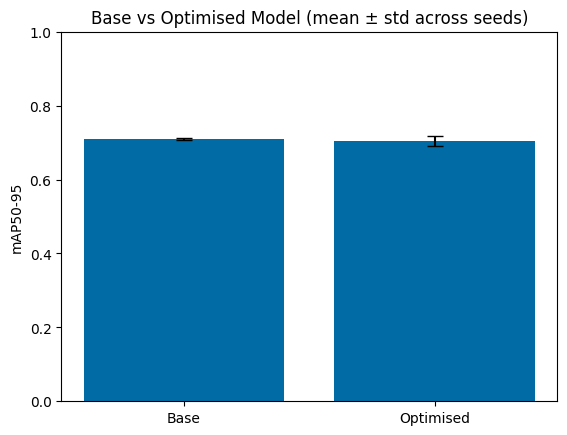

In [42]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('tableau-colorblind10')

base = np.array(best_mAP50_95_base)
optimised = np.array(best_mAP50_95_optimised)

means = [base.mean(), optimised.mean()]
stds = [base.std(), optimised.std()]
labels = ['Base', 'Optimised']

fig, ax = plt.subplots()

ax.bar(
    labels,
    means,
    yerr=stds,
    capsize=6
)

ax.set_ylabel('mAP50-95')
ax.set_title('Base vs Optimised Model (mean ± std across seeds)')
ax.set_ylim(0, 1)

plt.savefig(f"../data/raw/{dataset_name}/graphs/base_optimised_map50_95_mean.png", bbox_inches="tight")

plt.show()

In [49]:
df_base_list = []
df_optimal_list = []

for version in ['base', 'optimal']:
    for seed in [0, 24, 42, 1501]:

        df = pd.read_csv(
            f'../data/raw/{dataset_name}/data/runs/detect/{dataset_name}_{version}_seed_{seed}/results.csv'
        )

        df['seed'] = seed

        if version == 'base':
            df_base_list.append(df)

        else:
            df_optimal_list.append(df)

df_base = pd.concat(df_base_list, ignore_index=True)
df_optimal = pd.concat(df_optimal_list, ignore_index=True)

print(df_base.head())
print(df_optimal.head())

   epoch      time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1   9.00548         1.42572         3.21739         1.14289   
1      2  16.71970         1.38193         2.51485         1.18453   
2      3  24.28710         1.48781         1.98085         1.23751   
3      4  31.50680         1.45020         1.55078         1.22118   
4      5  38.85090         1.40669         1.29149         1.22547   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.00168            0.96203           0.04521   
1               0.62124            0.53984           0.62612   
2               0.89833            0.78290           0.85241   
3               0.92284            0.88608           0.94744   
4               0.91626            0.89873           0.95466   

   metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
0              0.02293       1.17085       4.05834       1.05685  0.000654   
1              0.37439       1.30371  

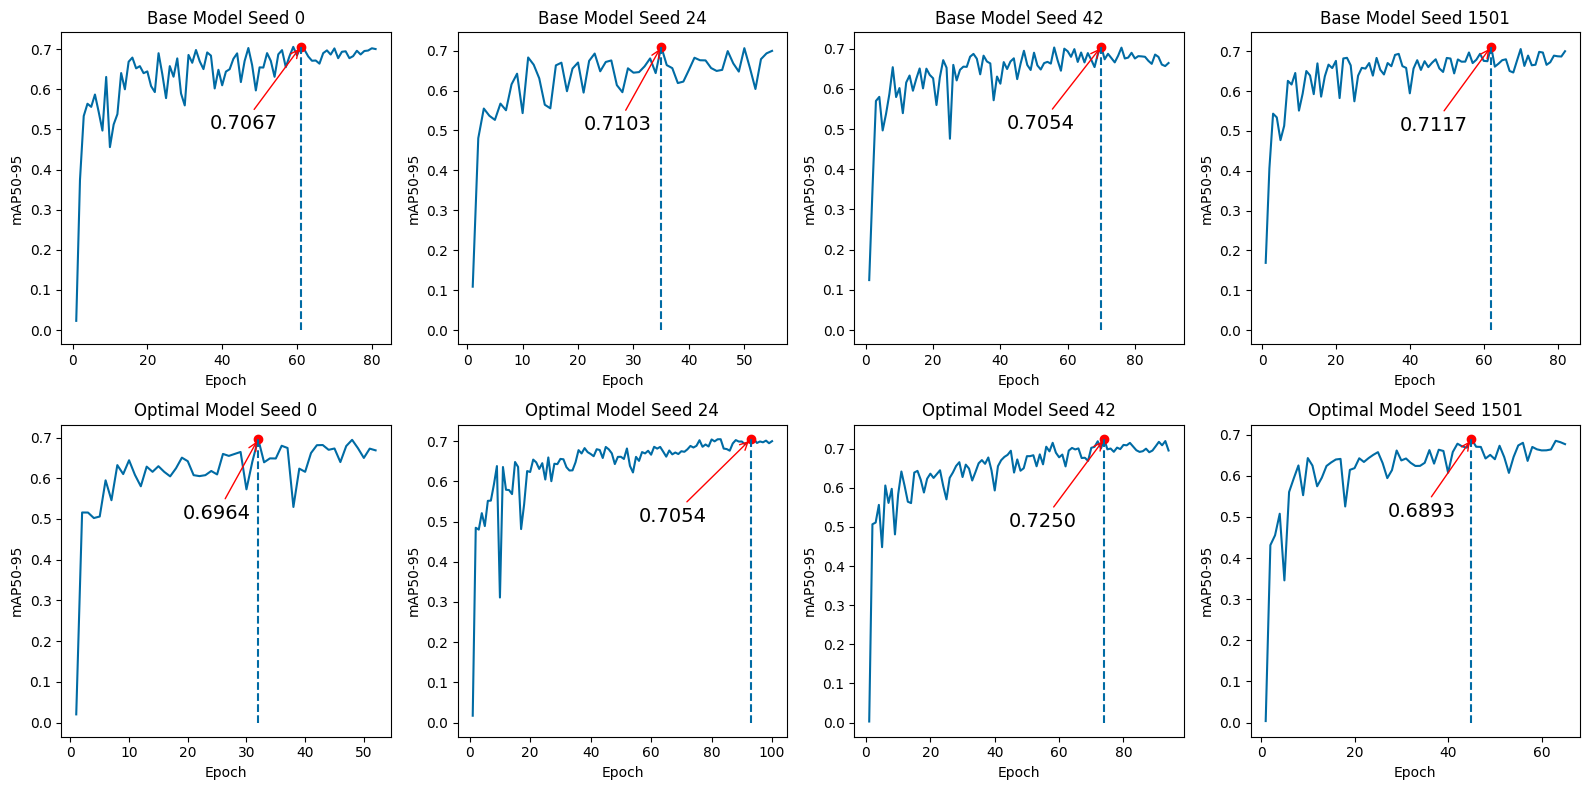

In [108]:
plt.style.use('tableau-colorblind10')

fig, ax = plt.subplots(nrows=2, ncols=4, figsize=[16,8])

for col, seed in enumerate([0, 24, 42, 1501]):

    mask_base = df_base['seed'] == seed
    best_epoch_base = df_base.loc[mask_base,'metrics/mAP50-95(B)'].idxmax()

    mask_optimal = df_optimal['seed'] == seed
    best_epoch_optimal = df_optimal.loc[mask_optimal,'metrics/mAP50-95(B)'].idxmax()

    ax[0, col].plot(df_base.loc[mask_base,'epoch'],
                    df_base.loc[mask_base,'metrics/mAP50-95(B)'])
    
    ax[0, col].plot(df_base.loc[best_epoch_base,'epoch'],
                    df_base.loc[best_epoch_base, 'metrics/mAP50-95(B)'],
                    'ro')

    ax[0, col].vlines(x=df_base.loc[best_epoch_base, 'epoch'],
                      ymin=0.0,
                      ymax=df_base.loc[best_epoch_base, 'metrics/mAP50-95(B)'],
                      linestyles='--')
    
    ax[0, col].annotate(f'{df_base.loc[best_epoch_base, 'metrics/mAP50-95(B)']:.4f}',
                        xy=(df_base.loc[best_epoch_base,'epoch'],
                            df_base.loc[best_epoch_base, 'metrics/mAP50-95(B)']),
                        xytext=(df_base.loc[best_epoch_base,'epoch'] *0.6,
                                0.5),
                        arrowprops=dict(arrowstyle='->', color='red'),
                        size=14)
    
    ax[0, col].set(title=f'Base Model Seed {seed}',
                   ylabel='mAP50-95',
                   xlabel='Epoch')
    
    ax[1, col].plot(df_optimal.loc[mask_optimal,'epoch'],
                    df_optimal.loc[mask_optimal,'metrics/mAP50-95(B)'])
    
    ax[1, col].plot(df_optimal.loc[best_epoch_optimal,'epoch'],
                    df_optimal.loc[best_epoch_optimal, 'metrics/mAP50-95(B)'],
                    'ro')

    ax[1, col].vlines(x=df_optimal.loc[best_epoch_optimal, 'epoch'],
                        ymin=0.0,
                        ymax=df_optimal.loc[best_epoch_optimal, 'metrics/mAP50-95(B)'],
                        linestyles='--')
    
    ax[1, col].annotate(f'{df_optimal.loc[best_epoch_optimal, 'metrics/mAP50-95(B)']:.4f}',
                        xy=(df_optimal.loc[best_epoch_optimal,'epoch'],
                            df_optimal.loc[best_epoch_optimal, 'metrics/mAP50-95(B)']),
                        xytext=(df_optimal.loc[best_epoch_optimal,'epoch'] *0.6,
                                0.5),
                        arrowprops=dict(arrowstyle='->', color='red'),
                        size=14)
    
    ax[1, col].set(title=f'Optimal Model Seed {seed}',
                   ylabel='mAP50-95',
                   xlabel='Epoch')
    
plt.tight_layout()
plt.savefig(f"../data/raw/{dataset_name}/graphs/base_optimised_map50_95_epoch.png", bbox_inches="tight")
plt.show()

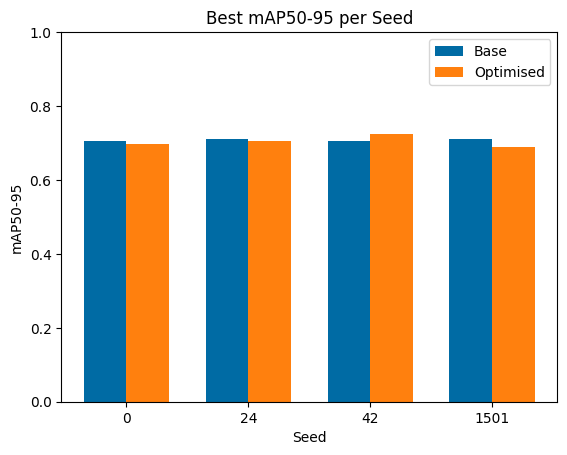

In [112]:
import numpy as np

plt.style.use('tableau-colorblind10')

seeds = [0, 24, 42, 1501]

base_max = [df_base.loc[df_base['seed']==s, 'metrics/mAP50-95(B)'].max() for s in seeds]

optimal_max = [df_optimal.loc[df_optimal['seed']==s, 'metrics/mAP50-95(B)'].max() for s in seeds]

x = np.arange(len(seeds))
width = 0.35

fig, ax = plt.subplots()

ax.bar(x - width/2, base_max, width, label='Base')
ax.bar(x + width/2, optimal_max, width, label='Optimised')

ax.set_xticks(x)
ax.set_xticklabels(seeds)
ax.set_ylim(0, 1)
ax.set_xlabel('Seed')
ax.set_ylabel('mAP50-95')
ax.set_title('Best mAP50-95 per Seed')
ax.legend()

plt.savefig(f"../data/raw/{dataset_name}/graphs/base_optimised_map50_95_grouped_bar.png", bbox_inches="tight")

plt.show()

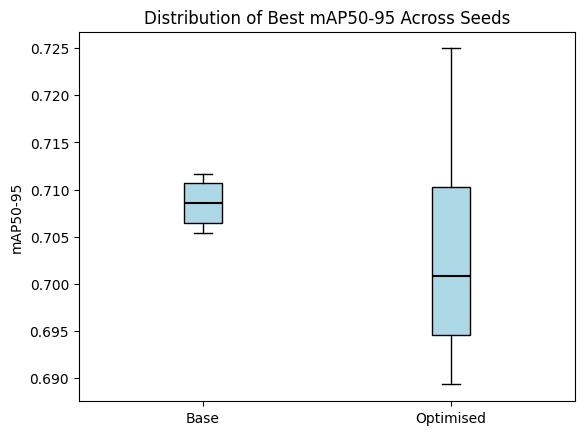

In [126]:
plt.style.use('tableau-colorblind10')

fig, ax = plt.subplots()

bp = ax.boxplot([base_max, optimal_max],
                 tick_labels=['Base', 'Optimised'],
                 patch_artist=True)

bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightblue')
bp['medians'][0].set_linewidth(1.5)
bp['medians'][1].set_linewidth(1.5)
bp['medians'][0].set_color('black')
bp['medians'][1].set_color('black')

ax.set_ylabel('mAP50-95')
ax.set_title('Distribution of Best mAP50-95 Across Seeds')

plt.savefig(f"../data/raw/{dataset_name}/graphs/base_optimised_map50_95_boxplot.png", bbox_inches="tight")

plt.show()

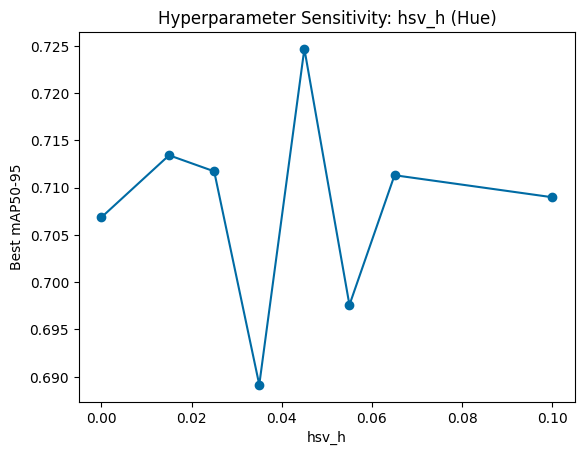

In [128]:
hsv_h_values = [0, 0.015, 0.025, 0.035, 0.045, 0.055, 0.065, 0.1]

rows = []

for h in hsv_h_values:
    results_path = f'../data/raw/{dataset_name}/data/runs/detect/{dataset_name}_hsv_h_{h}/results.csv'

    df = pd.read_csv(results_path)

    best_map = df['metrics/mAP50-95(B)'].max()

    rows.append({'hsv_h': h,
                 'best_mAP50_95': best_map})

df_hsv_h = pd.DataFrame(rows)

df_hsv_h

fig, ax = plt.subplots()
ax.plot(df_hsv_h['hsv_h'], df_hsv_h['best_mAP50_95'], marker='o')
ax.set_xlabel('hsv_h')
ax.set_ylabel('Best mAP50-95')
ax.set_title(f'Hyperparameter Sensitivity: hsv_h (Hue)')

plt.savefig(f"../data/raw/{dataset_name}/graphs/hsv_h_sensitivity.png", bbox_inches="tight")

plt.show()

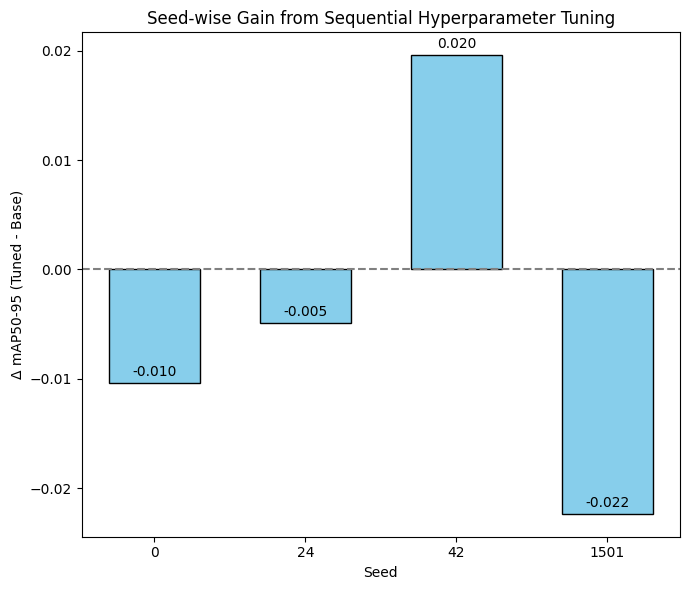

In [141]:
delta_map = [df_optimal.loc[df_optimal['seed']==s, 'metrics/mAP50-95(B)'].max() -
             df_base.loc[df_base['seed']==s, 'metrics/mAP50-95(B)'].max()
             for s in seeds]

x = np.arange(len(seeds))
width = 0.6

fig, ax = plt.subplots(figsize=(7,6))

bars = ax.bar(x, delta_map, width, color='skyblue', edgecolor='black')

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

ax.axhline(0, color='gray', linestyle='--')

ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in seeds])
ax.set_ylabel('Δ mAP50-95 (Tuned - Base)')
ax.set_xlabel('Seed')
ax.set_title('Seed-wise Gain from Sequential Hyperparameter Tuning')

plt.tight_layout()

plt.savefig(f"../data/raw/{dataset_name}/graphs/base_optimised_map50_95_delta.png", bbox_inches="tight")

plt.show()

In [145]:
base_model_path = f'../data/raw/{dataset_name}/data/runs/detect/{dataset_name}_base_seed_42/weights/best.pt'
optim_model_path = f'../data/raw/{dataset_name}/data/runs/detect/{dataset_name}_optimal_seed_42/weights/best.pt'

base_model = YOLO(base_model_path)
optimal_model = YOLO(optim_model_path)

test_images = f'../data/raw/{dataset_name}/data/testing_images/'

base_model.predict(source=test_images, save=True, project=f'../data/raw/{dataset_name}/data/runs/predict/', name='base')
optimal_model.predict(source=test_images, save=True, project=f'../data/raw/{dataset_name}/data/runs/predict/', name='optimised')


image 1/175 e:\GitHub\dpp\notebooks\..\data\raw\car-object-detection\data\testing_images\vid_5_25100.jpg: 384x640 (no detections), 37.5ms
image 2/175 e:\GitHub\dpp\notebooks\..\data\raw\car-object-detection\data\testing_images\vid_5_25120.jpg: 384x640 (no detections), 46.7ms
image 3/175 e:\GitHub\dpp\notebooks\..\data\raw\car-object-detection\data\testing_images\vid_5_25140.jpg: 384x640 (no detections), 33.2ms
image 4/175 e:\GitHub\dpp\notebooks\..\data\raw\car-object-detection\data\testing_images\vid_5_25160.jpg: 384x640 (no detections), 51.5ms
image 5/175 e:\GitHub\dpp\notebooks\..\data\raw\car-object-detection\data\testing_images\vid_5_25180.jpg: 384x640 (no detections), 36.6ms
image 6/175 e:\GitHub\dpp\notebooks\..\data\raw\car-object-detection\data\testing_images\vid_5_25200.jpg: 384x640 (no detections), 45.4ms
image 7/175 e:\GitHub\dpp\notebooks\..\data\raw\car-object-detection\data\testing_images\vid_5_25220.jpg: 384x640 (no detections), 6.2ms
image 8/175 e:\GitHub\dpp\notebook

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'car'}
 obb: None
 orig_img: array([[[254, 222, 187],
         [254, 222, 187],
         [251, 221, 186],
         ...,
         [239, 188, 138],
         [238, 187, 137],
         [238, 187, 137]],
 
        [[255, 223, 188],
         [255, 223, 188],
         [253, 223, 188],
         ...,
         [239, 188, 138],
         [239, 188, 138],
         [239, 188, 138]],
 
        [[254, 224, 189],
         [254, 224, 189],
         [254, 224, 189],
         ...,
         [239, 188, 138],
         [239, 188, 138],
         [240, 189, 139]],
 
        ...,
 
        [[ 57,  46,  38],
         [ 59,  48,  40],
         [ 60,  47,  39],
         ...,
         [ 38,  76, 100],
         [ 38,  75, 101],
         [ 38,  76, 100]],
 
        [[ 58,  44,  38],
         [ 59,  45,  39],
         [ 59,  45,  39],
         ...,
         [ 40,  77,  